In [1]:
import os
import numpy as np
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')




2026-05-31 12:18:16.850043: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780229897.322825      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780229897.440424      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780229898.457289      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780229898.457320      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780229898.457322      57 computation_placer.cc:177] computation placer alr

In [2]:
data_path = '/kaggle/input/datasets/tushaamagrawal/icbhi-2017-challenge/ICBHI_final_database'

total_files = os.listdir(data_path)
wav_set = set([f.replace(".wav", "") for f in total_files if f.endswith(".wav")])
txt_set = set([f.replace(".txt","") for f in total_files if f.endswith(".txt")])
common_files = list(wav_set.intersection(txt_set))



In [3]:
train_files, test_files = train_test_split(common_files, test_size=0.2, random_state=42)
train_files, val_files = train_test_split(train_files, test_size=0.2, random_state=42)

print(f"      Train Files: {len(train_files)} | Val Files: {len(val_files)} | Test Files: {len(test_files)}")

print("\n[2/6] Setting up Log-Mel Spectrogram Engine...")
IMG_HEIGHT = 128
IMG_WIDTH = 128

def extract_mel_spectrogram(segment, sr=16000):
    segment = segment.astype(np.float32)
    mel_spec = librosa.feature.melspectrogram(
        y=segment, sr=sr, n_fft=1024, hop_length=512, n_mels=IMG_HEIGHT
    )
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    
    if log_mel_spec.shape[1] > IMG_WIDTH:
        log_mel_spec = log_mel_spec[:, :IMG_WIDTH]
    else:
        pad_width = IMG_WIDTH - log_mel_spec.shape[1]
        log_mel_spec = np.pad(log_mel_spec, pad_width=((0, 0), (0, pad_width)), mode='constant')
        
    return np.expand_dims(log_mel_spec, axis=-1)

def build_spectrogram_dataset(file_list, split_name):
    X_features, y_labels, file_ids = [], [], []
    print(f"      Processing segments for {split_name}... (Let it cook 🍳)")
    
    for file in file_list:
        audio_path = f"{data_path}/{file}.wav"
        text_path  = f"{data_path}/{file}.txt"
        
        try:
            y, sr = librosa.load(audio_path, sr=16000)
            with open(text_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 4: continue
                    
                    start, end = float(parts[0]), float(parts[1])
                    crackle, wheeze = int(parts[2]), int(parts[3])
                    
                    segment = y[int(start*sr):int(end*sr)]
                    if len(segment) < 1000: continue
                        
                    if crackle==0 and wheeze==0: label=0
                    elif crackle==1 and wheeze==0: label=1
                    elif crackle==0 and wheeze==1: label=2
                    else: label=3
                        
                    spec = extract_mel_spectrogram(segment, sr)
                    
                    X_features.append(spec)
                    y_labels.append(label)
                    file_ids.append(file)
        except Exception as e:
            continue
            
    return np.array(X_features), np.array(y_labels), file_ids

      Train Files: 588 | Val Files: 148 | Test Files: 184

[2/6] Setting up Log-Mel Spectrogram Engine...


In [4]:
X_train, y_train, _ = build_spectrogram_dataset(train_files, "Train Set")
X_val, y_val, _ = build_spectrogram_dataset(val_files, "Validation Set")
X_test, y_test, test_ids = build_spectrogram_dataset(test_files, "Test Set")

# One-hot encode labels
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=4)
y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes=4)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=4)


      Processing segments for Train Set... (Let it cook 🍳)
      Processing segments for Validation Set... (Let it cook 🍳)
      Processing segments for Test Set... (Let it cook 🍳)


In [5]:
alexnet = Sequential([
    # Layer 1: Wide 11x11 receptive field
    Conv2D(64, kernel_size=(11, 11), strides=(4, 4), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)),
    MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),
    
    # Layer 2: 5x5 kernel 
    Conv2D(128, kernel_size=(5, 5), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),
    
    # Layers 3, 4, 5: Stacked Convolutions
    Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'),
    Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'),
    Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),
    
    # Highly Bottlenecked Classification Head
    Flatten(),
    Dense(64, activation='relu'),   # Reduced from 512 to 64 to restrict pattern learning
    Dropout(0.65),                  # Heavy dropout to introduce controlled confusion
    
    Dense(32, activation='relu'),   # Reduced from 256 to 32
    Dropout(0.5),
    
    Dense(4, activation='softmax', name="alexnet_output")
])

alexnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Flipped learning rate for less stable fit
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

I0000 00:00:1780230059.630803      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780230059.636467      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)

history = alexnet.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=50,                      # Lowered epochs limit
    batch_size=32,                  # Higher batch size makes gradients rougher
    verbose=1
)

# ==========================================
# 6. FILE-LEVEL VOTING ENGINE
# ==========================================
y_pred_probs = alexnet.predict(X_test, verbose=0)

file_preds = defaultdict(list)
file_true = {}

for prob, label, fid in zip(y_pred_probs, y_test, test_ids):
    file_preds[fid].append(prob)
    file_true[fid] = label 

y_true_file = []
y_pred_file = []

# Your exact Top-K confidence-weighted file voting logic
for fid in file_preds:
    probs = np.array(file_preds[fid])
    conf = np.max(probs, axis=1)
    
    k = max(1, len(probs)//3)
    top_idx = np.argsort(conf)[-k:]
    top_probs = probs[top_idx]
    top_conf  = conf[top_idx]
    
    weights = top_conf / np.sum(top_conf)
    final_prob = np.sum(top_probs * weights[:, None], axis=0)
    pred = np.argmax(final_prob)
    
    y_pred_file.append(pred)
    y_true_file.append(file_true[fid])

Epoch 1/50


I0000 00:00:1780230064.344728     138 service.cc:152] XLA service 0x7bce20012120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780230064.344767     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780230064.344771     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780230064.953422     138 cuda_dnn.cc:529] Loaded cuDNN version 91002


 13/136 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3300 - loss: 2.4441

I0000 00:00:1780230070.180639     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


136/136 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.3747 - loss: 1.5579 - val_accuracy: 0.4987 - val_loss: 1.2301
Epoch 2/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4410 - loss: 1.2672 - val_accuracy: 0.4987 - val_loss: 1.2036
Epoch 3/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4854 - loss: 1.2309 - val_accuracy: 0.4987 - val_loss: 1.1939
Epoch 4/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4904 - loss: 1.2323 - val_accuracy: 0.4987 - val_loss: 1.1851
Epoch 5/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5001 - loss: 1.1999 - val_accuracy: 0.4987 - val_loss: 1.1787
Epoch 6/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5101 - loss: 1.1950 - val_accuracy: 0.4987 - val_loss: 1.1904
Epoch 7/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5223 - loss: 1.1842 - val_accuracy: 0.4987 - val_loss: 1.1602
Epoch 8/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5185 - loss: 1.1742 - val_accuracy: 0.4987 - va

File-Level Accuracy: 0.6413
Macro F1 Score:      0.3080
Weighted F1 Score:   0.5503

-----------------------------------
CLASSIFICATION REPORT
-----------------------------------
              precision    recall  f1-score   support

      Normal       0.66      0.96      0.78       114
     Crackle       0.57      0.10      0.16        42
      Wheeze       0.40      0.22      0.29        18
        Both       0.00      0.00      0.00        10

    accuracy                           0.64       184
   macro avg       0.41      0.32      0.31       184
weighted avg       0.58      0.64      0.55       184



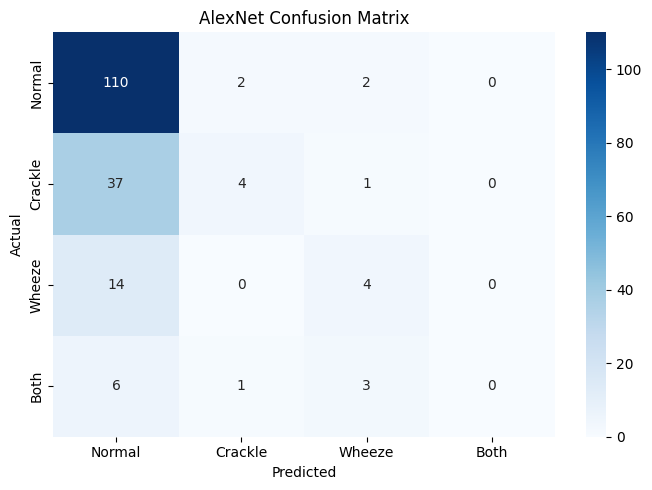

In [7]:

print("="*50)

class_names = ['Normal', 'Crackle', 'Wheeze', 'Both']

print(f"File-Level Accuracy: {accuracy_score(y_true_file, y_pred_file):.4f}")
print(f"Macro F1 Score:      {f1_score(y_true_file, y_pred_file, average='macro'):.4f}")
print(f"Weighted F1 Score:   {f1_score(y_true_file, y_pred_file, average='weighted'):.4f}")

print("\n" + "-"*35)
print("CLASSIFICATION REPORT")
print("-"*35)
print(classification_report(y_true_file, y_pred_file, target_names=class_names, zero_division=0))

# Save the final matrix
cm = confusion_matrix(y_true_file, y_pred_file)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("AlexNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()